<a href="https://colab.research.google.com/github/Sairam307/ML-regression-project/blob/main/Customer_Churn_Analysis_Using_Classification_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Analysis Using Regression Algorithms**

You are the Data Scientist at a telecom company “Neo” whose customers are churning out to
its competitors. You have to analyse the data of your company and find insights and stop your
customers from churning out to other telecom companies.

## **1. Import Libraries & Check Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, classification_report, mean_absolute_error
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Upload Dataset
from google.colab import files
uploaded = files.upload()  # Upload daily_prices.csv

Saving customer churn.csv to customer churn.csv


In [3]:
data = pd.read_csv('customer churn.csv')

In [ ]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
data.size

147903

# **2.EDA**

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **3.Data Cleaning**

In [12]:
# Duplicates
data.duplicated().sum()

np.int64(0)

In [13]:
#MIssing data
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


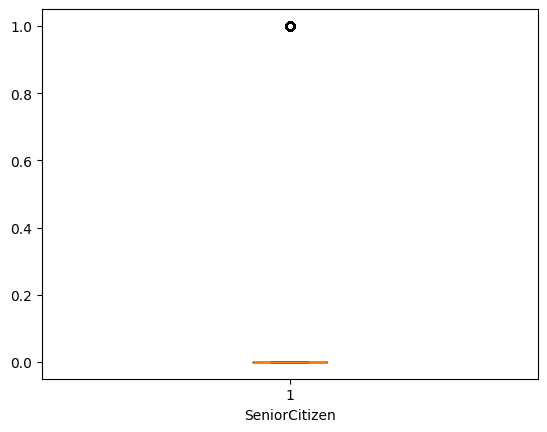

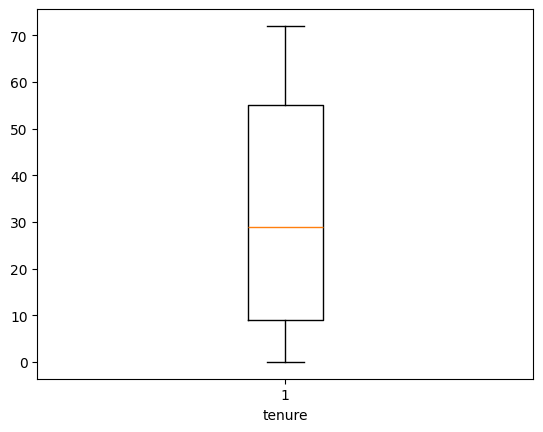

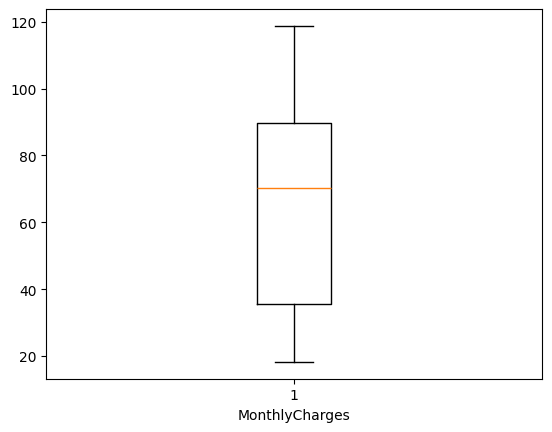

In [14]:
#Outliers
for i in data.columns:
  if data[i].dtypes != object:
    plt.boxplot(data[i])
    plt.xlabel(i)
    plt.show()

### **4. Tasks**

4.1 Data Manipulation:


1.   Extract the 5th column & store in 'customer_5'
2.   Extract the 15 th column & store it in 'customer_15'
3.   Extract all the male senior citizens whose payment method is electronic check & store the result in 'senior_male_electronic'
4.   extract all those customers whose tenure is greater than 70 months or their monthly charges is more than 100$ & store the result in 'customer_total_tenure'
5.   extract all the customers whose contract is of two years, payment methods is mailed check & the value of churn is 'Yes' & store the result in 'two_mail_yes'
6.   Extract 333 random records from the customer_churn dataframe & store the result in 'customer_333'
7.   Get the count of different levels from the 'churn' column





In [17]:
#Extract the 5th column & store it in 'customer_5'
customer_5 = data.iloc[:,4]
data['customer_5'] = customer_5
customer_5.sample(2)

,Dependents
4456,No
1503,No


In [19]:
#2. Extract the 15th column & store it in 'customer_15'
customer_15 = data.iloc[:,14]
data['customer_15'] = customer_15
customer_15.sample(2)

,StreamingMovies
6853,Yes
5947,No internet service


# **Important Note**

In [20]:
#To check Index of Columns
pp = list(data.columns)
for x,y in enumerate(pp):
  print(x,y)

0 customerID
1 gender
2 SeniorCitizen
3 Partner
4 Dependents
5 tenure
6 PhoneService
7 MultipleLines
8 InternetService
9 OnlineSecurity
10 OnlineBackup
11 DeviceProtection
12 TechSupport
13 StreamingTV
14 StreamingMovies
15 Contract
16 PaperlessBilling
17 PaymentMethod
18 MonthlyCharges
19 TotalCharges
20 Churn
21 customer_5
22 customer_15


In [21]:
#3. Extract all the male senior citizens whose payment method is electronic check & store the result in 'senior_male_electronic
Senior_male_electronics = data[(data['gender'] == 'Male') & (data['SeniorCitizen'] == 1) &
                               (data['PaymentMethod'] == 'Electronic check')]
Senior_male_electronics.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_5,customer_15
1639,4690-LLKUA,Male,1,No,No,17,Yes,No,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,45.05,770.6,Yes,No,No
2775,2634-HCZGT,Male,1,Yes,No,53,Yes,Yes,DSL,Yes,...,No,No,One year,Yes,Electronic check,60.05,3229.65,Yes,No,No
3163,9281-OFDMF,Male,1,No,No,39,Yes,Yes,Fiber optic,No,...,No,Yes,Month-to-month,No,Electronic check,90.70,3413.25,No,No,Yes


In [22]:
#4. Extract all those customers whose tenure is grater than 70 months or their monthly charges is more than 100$ store the result in 'customer-total_tenure'
customer_total_tenure = data[(data['tenure']>70) | (data['MonthlyCharges']>100)]
customer_total_tenure.sample(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_5,customer_15
4835,2360-RDGRO,Male,0,Yes,No,65,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.25,6812.95,No,No,Yes
4086,2235-EZAIK,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,No,Two year,No,Credit card (automatic),79.20,5401.9,No,No,No


In [24]:
#5. Extract all the customers whose contract is of two years, payment method is mailed check & the value of Churn is 'Yes' & store the result in 'two_mailyes'
two_mail_yes = data[(data['Contract'] == 'Two year') & (data['PaymentMethod'] == 'Mailed check') & (data['Churn'] == 'Yes')]
two_mail_yes.sample(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_5,customer_15
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.6,Yes,No,No internet service
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes,Yes,No


In [26]:
#6. Extract 333 random records from the customer_churn dataframe & store the result in 'cutomer_333'
customer_333 = data.sample(333)
customer_333.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_5,customer_15
3432,8174-TBVCF,Female,0,Yes,No,70,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),94.80,6859.05,No,No,Yes
6394,2680-XKKNJ,Female,0,No,No,8,Yes,No,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),58.20,469.25,No,No,No
5654,1576-PFZIW,Male,1,Yes,No,70,Yes,No,Fiber optic,Yes,...,Yes,Yes,Two year,No,Credit card (automatic),105.35,7511.9,No,No,Yes
888,0048-LUMLS,Male,0,Yes,Yes,37,Yes,No,Fiber optic,No,...,Yes,Yes,One year,No,Credit card (automatic),91.20,3247.55,No,Yes,Yes
6100,3565-UNOCC,Female,1,Yes,No,29,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.05,2952.85,Yes,No,Yes


In [27]:
#7. Get the count of different levels from the 'Churn' column
data.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869


# **4.2 Data Visulization:**

  1. Build a bar-plot for the 'InternetService' column:

      *   Set x-axis label to 'Categories of Internet Service
      *   Set y-axis label to 'Count of categories
      *   Set the title of plot to be 'Distribution of Internet Service'
      *   Set the color of the bars to be 'orange'

  2. Build a histogram for the 'tenure' column':

      *   Set the number of bins to be 'green'
      Assign the title 'Distribution of tenure'
  
  3. Build a scatter-plot between 'MonthlyCharges' & 'tenure'. Map 'MonthlyCharges' to the y-axis & 'tenure' to to the 'x-axis':
      
      * Assign the points a color of 'brown'
      * Set the x-axis label to 'Monthly Charges of customer'
      * Set the y-axis label to 'Monthly Charges of customer'
      * Set the title to 'Tenure vs Monthly Charges'
  
  4. Build a box-plot between 'tenure' & 'Contract'

      * Map 'tenure' on the y-axis & 'Contract' on the x-axis.






In [29]:
#1. Build a bar-plot for the 'InternetService' column
x = data.InternetService.value_counts().index
y = data.InternetService.value_counts()

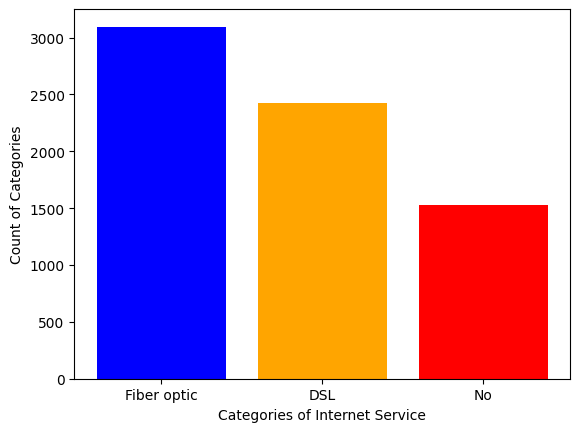

<Figure size 640x480 with 0 Axes>

In [30]:
plt.bar(x,y, color = ['blue', 'orange', 'red'])
plt.xlabel('Categories of Internet Service')
plt.ylabel('Count of Categories')
plt.show()
plt.tight_layout();

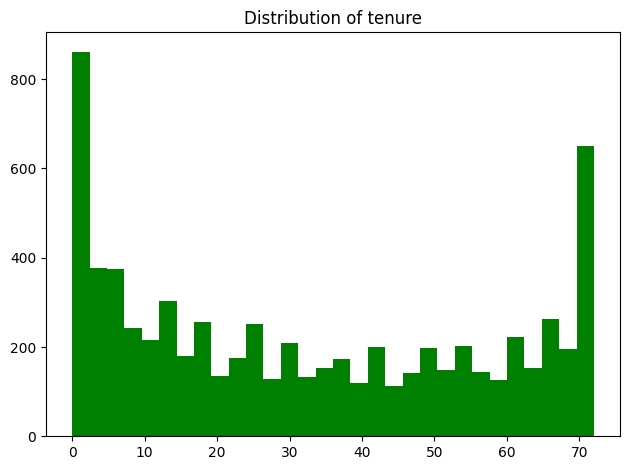

In [31]:
#. Build a histogram for the 'tenure' column':
plt.title('Distribution of tenure')
plt.hist(data.tenure, bins = 30, color = 'green')
plt.tight_layout();

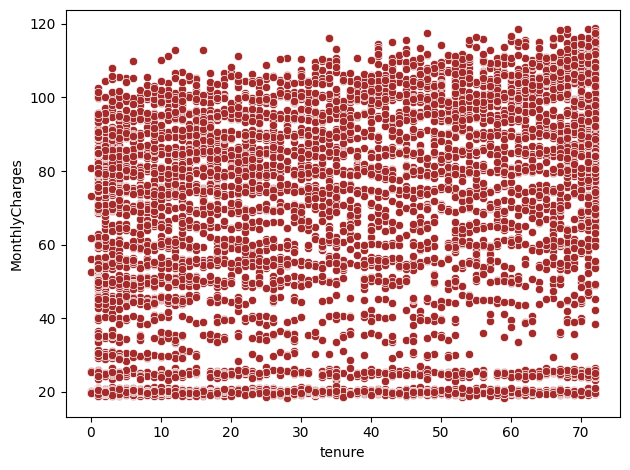

In [32]:
#3. Build a scatter-plot between 'MomnthlyCharges' & tenure'. Map 'MonthlyCharges' to the y-axis & 'tenure' to the 'x-axis:
plt.title = 'Tenure vs Montly Charges'
sns.scatterplot(y = 'MonthlyCharges', x = 'tenure', data = data, color = 'brown')
plt.xlabel = 'tenure of customer'
plt.ylabel = 'Montly Charges of customer'
plt.tight_layout()
plt.show();

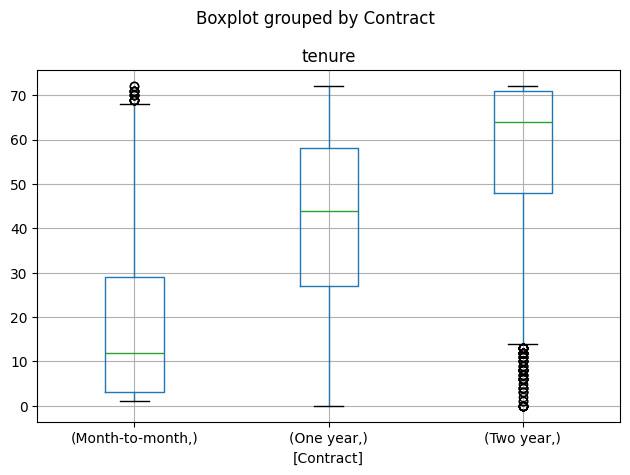

In [35]:
data.boxplot('tenure', by=['Contract'])
plt.tight_layout();
plt.show();

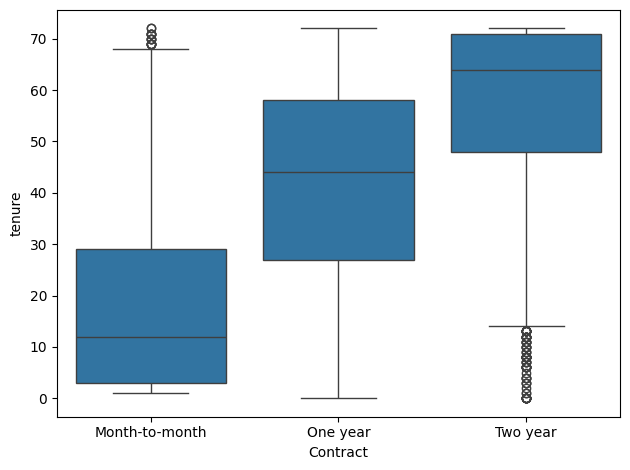

In [42]:
#4. Build a box-plot between 'tenure' & 'Contract':
sns.boxplot(x = 'Contract', y = 'tenure', data = data)
plt.tight_layout();
plt.show();